📊 Clusterización de artículos aplicables a forecast

Este notebook desarrolla la segmentación matemática de los artículos que aplican a forecast, utilizando variables construidas a partir del historial de ventas de los últimos 24 meses.

Procedimiento general

1. Importación del dataset preparado
Carga de la base filtrada y enriquecida proveniente del notebook anterior.

2. Validación de variables
Revisión de columnas, tipos de datos, valores nulos, infinitos y consistencia general.

3. Selección de variables de clusterización
Uso de variables finales asociadas a volumen, frecuencia, intermitencia, recencia, variabilidad, picos, tendencia y estacionalidad.

4. Preparación de la matriz de datos
Separación entre columnas de identificación del artículo y variables numéricas para modelado.

5. Escalamiento de variables
Estandarización de los datos para evitar que variables de mayor magnitud dominen el agrupamiento.

6. Evaluación del número óptimo de clusters
Aplicación del método del codo, Silhouette Score y análisis visual.

7. Aplicación de modelos de clusterización
Prueba inicial con K-Means y posible comparación con otros métodos no supervisados.

8. Visualización de resultados
Uso de PCA y gráficos exploratorios para observar la separación de los grupos.

9. Fotografía matemática por cluster
Análisis de promedios, medianas, dispersión y distribución de artículos por grupo.

10. Interpretación de clusters
Asignación de nombres descriptivos según el comportamiento histórico de demanda.

11. Preparación para forecast por grupo
Uso de los clusters como base para comparar modelos predictivos y seleccionar el algoritmo más adecuado por tipo de demanda.

In [155]:
# ============================================================
# 1. Importación de librerías
# ============================================================
# Se importan las librerías necesarias para manipulación de datos,
# visualización, escalamiento, clusterización y evaluación de clusters.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [156]:
from datetime import datetime

# ============================================================
# Exportar dataset preparado para clusterización
# ============================================================

fecha_hoy = datetime.today().strftime("%Y_%m_%d")

nombre_archivo = f"df_a_clusterizar_variables_cluster_final_2026_07_24.xlsx"

ruta=f"./Datos/{nombre_archivo}"


In [157]:
# ============================================================
# 2. Carga del dataset preparado para clusterización
# ============================================================
# Este archivo proviene del notebook anterior, donde se filtraron
# los artículos que aplican a forecast y se calcularon las variables
# matemáticas de comportamiento histórico de venta.
# ============================================================

df_cluster = pd.read_excel(ruta)

df_cluster.head()

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,aplica_forecast,motivo_aplica_forecast,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,US2: QF120A,Interruptor 20 A 1P 120 V 10K QPF2 GFCI 5MA,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CENTROS DE CARGA E INTERRUPTORES,NaN,SIEMENS,UNI,True,Aplica forecast,11225.00,67,0.845612,4,0,15.180870,-0.668349,0.495099
1,W8,"Cinta para husos, Habasit, W-8",FAJAS,BANDAS,CORREAS PLANAS DE TRANSMISION,CORREAS PLANAS DE TRANSMISION,HABASIT ROCUA,CM2,True,Aplica forecast,5975816.38,56,0.964050,4,1,-5326.251196,-0.275883,0.989061
2,RB330-3PLY-30''-SHRD,"Banda de Hule y lona de 30""",FAJAS,CORREAS,REDONDAS,REDONDAS,SHARDA,MT,True,Aplica forecast,2058.42,47,0.507788,2,1,-0.823330,-0.224816,1.285581
3,C3.5-TEH-14.984,RODILLO RETRO PSV/1.20F14.89N.38,POLEAS RODI.Y TAMB.,NaN,NaN,NaN,PRECISION INC,UNI,True,Aplica forecast,572.00,20,1.349650,6,0,1.013913,-0.137333,0.507343
4,RB330-3PLY-24''-SHRD,"Banda de Hule y lona de 24"" 3 lonas",FAJAS,CORREAS,REDONDAS,REDONDAS,SHARDA,MT,True,Aplica forecast,1393.68,46,1.223552,3,0,0.652261,-0.291110,0.661989


In [158]:
# ============================================================
# 3. Validación inicial del dataset
# ============================================================

print("Dimensiones del dataset:")
print(df_cluster.shape)

print("\nColumnas disponibles:")
print(df_cluster.columns.tolist())

print("\nTipos de datos:")
df_cluster.info()

Dimensiones del dataset:
(450, 18)

Columnas disponibles:
['codigo_articulo', 'descripcion_completa', 'grupo_articulo', 'categoria', 'subcategoria', 'tipo', 'marca_fabricante', 'unidad_medida_inventario', 'aplica_forecast', 'motivo_aplica_forecast', 'total_unidades_vendidas_24m', 'conteo_facturas_24m', 'ratio_venta_reciente_6m', 'cantidad_meses_pico_24m', 'meses_desde_ultima_venta', 'pendiente_tendencia_24m', 'correlacion_estacional_12m', 'cv_meses_con_venta_24m']

Tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   codigo_articulo              450 non-null    str    
 1   descripcion_completa         449 non-null    str    
 2   grupo_articulo               450 non-null    str    
 3   categoria                    411 non-null    str    
 4   subcategoria                 411 non-null    str    
 5   tipo     

In [159]:
# ============================================================
# 3.1 Revisión rápida de valores nulos
# ============================================================

nulos = (
    df_cluster
    .isna()
    .sum()
    .sort_values(ascending=False)
)

nulos[nulos>0]

tipo                    44
categoria               39
subcategoria            39
descripcion_completa     1
dtype: int64

 10  total_unidades_vendidas_24m  450 non-null    float64
 11  conteo_facturas_24m          450 non-null    int64  
 12  ratio_venta_reciente_6m      450 non-null    float64
 13  cantidad_meses_pico_24m      450 non-null    int64  
 14  meses_desde_ultima_venta     450 non-null    int64  
 15  pendiente_tendencia_24m      450 non-null    float64
 16  correlacion_estacional_12m   450 non-null    float64
 17  cv_meses_con_venta_24m

In [160]:
# ============================================================
# 4. Variables finales para clusterización
# ============================================================
# Estas variables fueron seleccionadas después de analizar redundancia
# mediante matriz de correlación y representan diferentes dimensiones
# del comportamiento histórico de venta.
# ============================================================

variables_cluster_final = [
    "total_unidades_vendidas_24m",
    "conteo_facturas_24m",
    "ratio_venta_reciente_6m",
    "cantidad_meses_pico_24m",
    "meses_desde_ultima_venta",
    "pendiente_tendencia_24m",
    "correlacion_estacional_12m",
    "cv_meses_con_venta_24m"
]

In [161]:
# ============================================================
# 4.1 Validar que todas las variables existan en el DataFrame
# ============================================================

variables_faltantes = [
    variable for variable in variables_cluster_final
    if variable not in df_cluster.columns
]

if len(variables_faltantes) == 0:
    print("✅ Todas las variables de clusterización existen en el DataFrame.")
else:
    print("⚠️ Variables faltantes:")
    print(variables_faltantes)

✅ Todas las variables de clusterización existen en el DataFrame.


In [162]:
# ============================================================
# 5. Separar columnas de identificación y variables numéricas
# ============================================================
# Los identificadores se conservan para interpretar los resultados,
# pero no se utilizan como entrada del algoritmo de clusterización.
# ============================================================

columnas_identificacion = [
    "codigo_articulo",
    "descripcion_completa",
    "grupo_articulo",
    "categoria",
    "subcategoria",
    "tipo",
    "marca_fabricante",
    "unidad_medida_inventario", 
    "aplica_forecast", 
    "motivo_aplica_forecast"
]

# Conservar únicamente las columnas de identificación que existan
columnas_identificacion = [
    col for col in columnas_identificacion
    if col in df_cluster.columns
]

df_identificacion = df_cluster[columnas_identificacion].copy()

# Matriz de variables matemáticas para clusterización
X = df_cluster[variables_cluster_final].copy()

X.head()

,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,11225.00,67,0.845612,4,0,15.180870,-0.668349,0.495099
1,5975816.38,56,0.964050,4,1,-5326.251196,-0.275883,0.989061
2,2058.42,47,0.507788,2,1,-0.823330,-0.224816,1.285581
3,572.00,20,1.349650,6,0,1.013913,-0.137333,0.507343
4,1393.68,46,1.223552,3,0,0.652261,-0.291110,0.661989


In [163]:
# ============================================================
# 6. Limpieza de matriz numérica
# ============================================================
# Se convierten las variables a formato numérico, se reemplazan
# valores infinitos y se imputan valores nulos con 0.
# ============================================================

X = (
    X
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

X.describe().T

,count,mean,std,min,25%,50%,75%,max
total_unidades_vendidas_24m,450.0,84939.830356,583677.707659,12.000000,30.000000,69.000000,367.500000,6.219703e+06
conteo_facturas_24m,450.0,21.888889,23.823892,6.000000,9.250000,14.000000,24.000000,2.120000e+02
ratio_venta_reciente_6m,450.0,0.840109,0.564918,0.000000,0.425024,0.761905,1.142857,3.100000e+00
cantidad_meses_pico_24m,450.0,3.491111,1.373034,1.000000,3.000000,3.500000,4.000000,1.000000e+01
meses_desde_ultima_venta,450.0,1.800000,2.193329,0.000000,0.000000,1.000000,3.000000,1.300000e+01
pendiente_tendencia_24m,450.0,-28.071955,675.591955,-6622.842487,-0.116848,-0.028696,0.072935,6.461302e+03
correlacion_estacional_12m,450.0,-0.011506,0.303846,-0.668349,-0.241708,-0.082825,0.177860,9.573920e-01
cv_meses_con_venta_24m,450.0,0.742775,0.284956,0.202031,0.571410,0.690622,0.873531,2.475595e+00


## Antes de proceder con el escalado de variables de clusterización, analizaremos su distribución para evaluar si es necesario realizar una transformación previa al escalado. 
esto con el fin de evitar escalar un variable con una tendencia muy sesgada, esto pudiera generar un error metodologico dando lugar a una clusterización sin sentido practico donde k-means=2 (Valores normales Vs Valores atipicos)

Transformación de variables previo a la clusterización

Antes de aplicar algoritmos de clusterización, se revisa la distribución de las variables seleccionadas. Este paso es necesario porque K-Means utiliza distancias entre observaciones, por lo que variables con colas largas, sesgo pronunciado u outliers extremos pueden dominar el agrupamiento.

El objetivo de esta sección es aplicar transformaciones diferenciadas según la naturaleza matemática de cada variable. Para variables positivas con fuerte sesgo hacia la derecha se utilizará transformación logarítmica log1p; para variables con valores negativos o distribuciones con outliers severos se evaluará Yeo-Johnson; y posteriormente se aplicará escalamiento robusto para reducir la influencia de valores extremos.

Este procedimiento busca que la clusterización capture patrones reales de comportamiento histórico de demanda, en lugar de separar únicamente artículos típicos frente a artículos extremos.

In [164]:
# ============================================================
# Análisis de distribución de variables de clusterización
# ============================================================
# Objetivo:
# Revisar la forma de distribución de cada variable antes de decidir
# si conviene aplicar StandardScaler, RobustScaler, transformación logarítmica
# u otro tratamiento previo a la clusterización.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [165]:
# ============================================================
# 1. Preparar matriz base para transformación
# ============================================================
# Se parte de la matriz X original, antes del escalamiento.
# Esta matriz contiene únicamente variables numéricas de comportamiento
# histórico de venta.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler, StandardScaler, PowerTransformer

X_base= X.copy()

X_base = (
    X_base
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

X_base.head()

,total_unidades_vendidas_24m,conteo_facturas_24m,ratio_venta_reciente_6m,cantidad_meses_pico_24m,meses_desde_ultima_venta,pendiente_tendencia_24m,correlacion_estacional_12m,cv_meses_con_venta_24m
0,11225.00,67,0.845612,4,0,15.180870,-0.668349,0.495099
1,5975816.38,56,0.964050,4,1,-5326.251196,-0.275883,0.989061
2,2058.42,47,0.507788,2,1,-0.823330,-0.224816,1.285581
3,572.00,20,1.349650,6,0,1.013913,-0.137333,0.507343
4,1393.68,46,1.223552,3,0,0.652261,-0.291110,0.661989


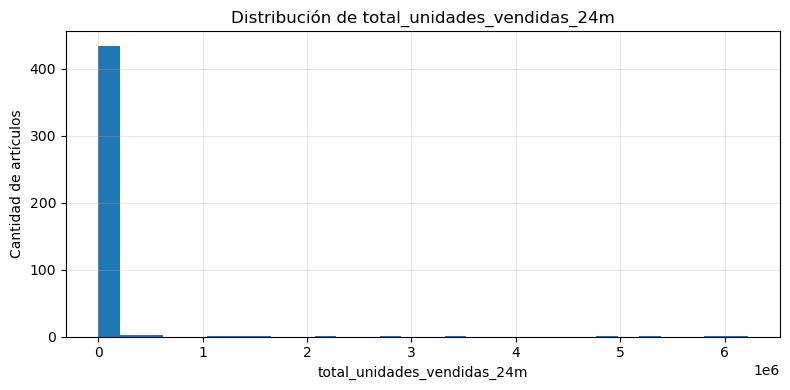

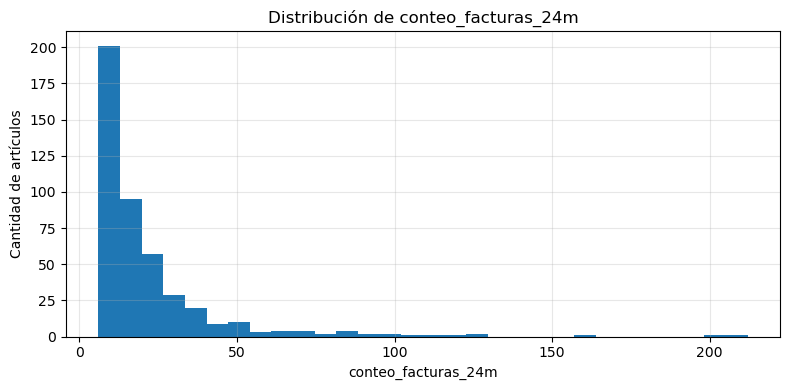

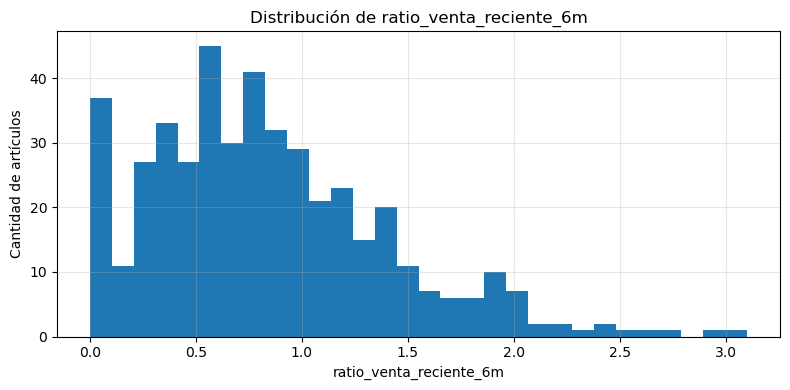

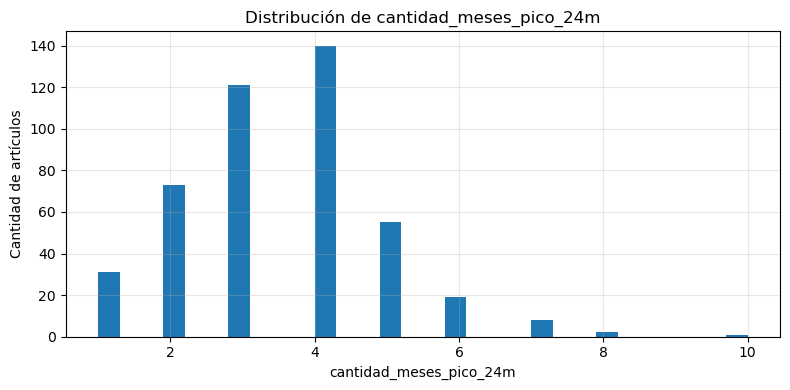

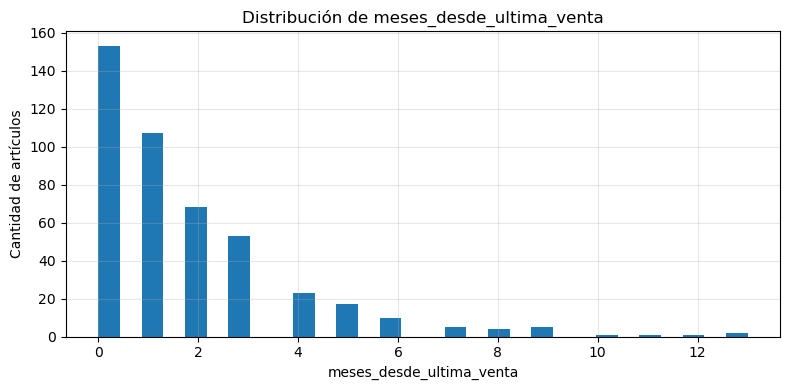

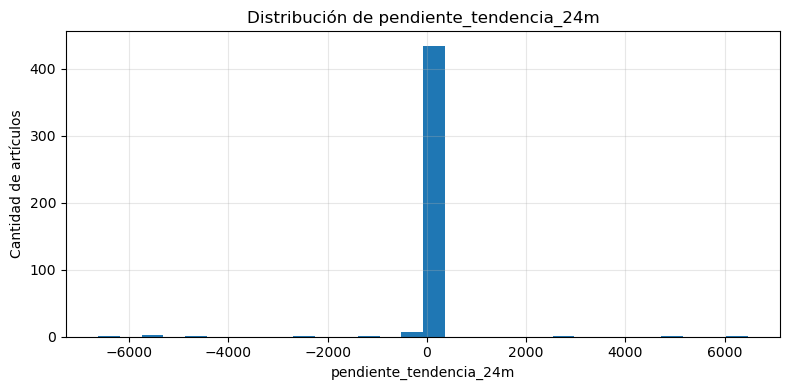

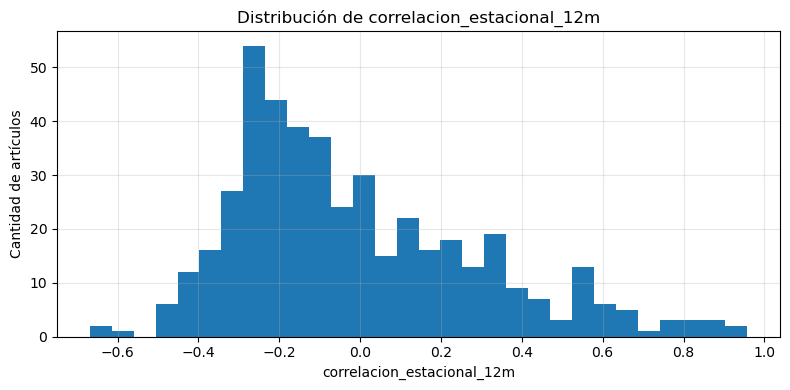

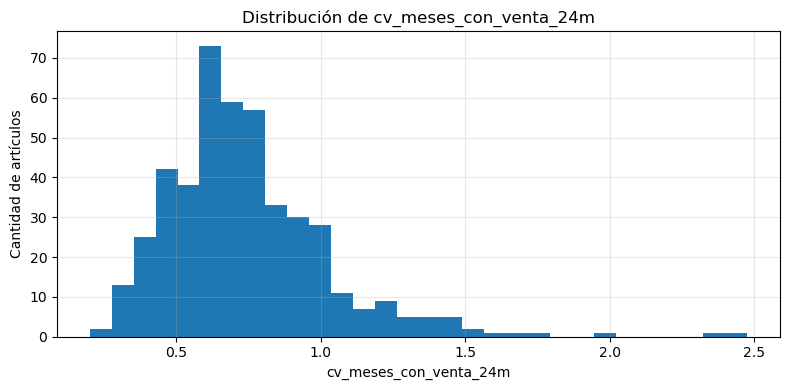

In [166]:
# ============================================================
# 4. Histogramas individuales por variable
# ============================================================
# Permiten observar visualmente si la variable tiene concentración,
# cola larga, muchos ceros o valores extremos.
# ============================================================

for variable in variables_cluster_final:
    plt.figure(figsize=(8, 4))

    plt.hist(
        X_base[variable].dropna(),
        bins=30
    )

    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Cantidad de artículos")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

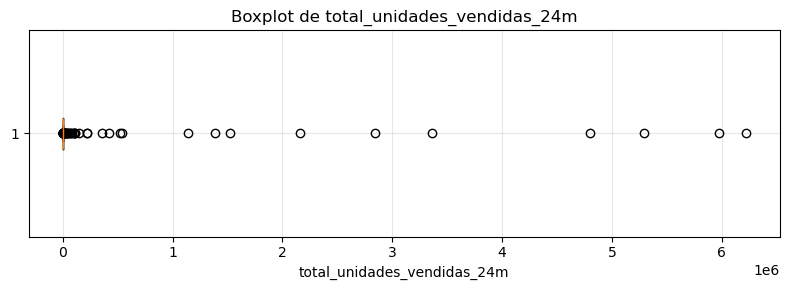

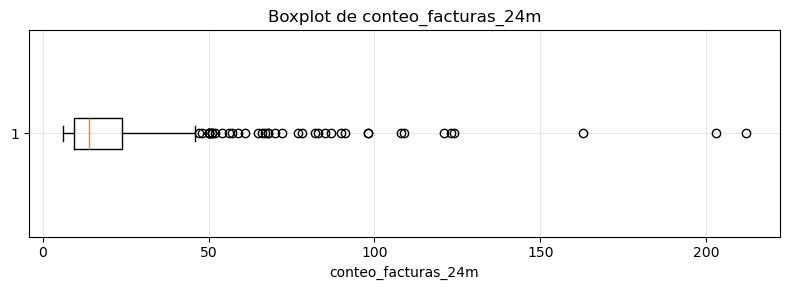

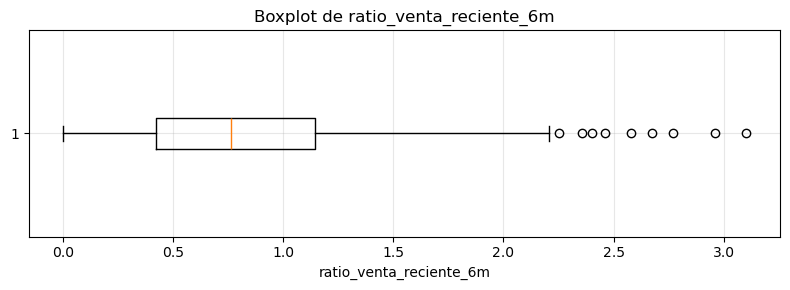

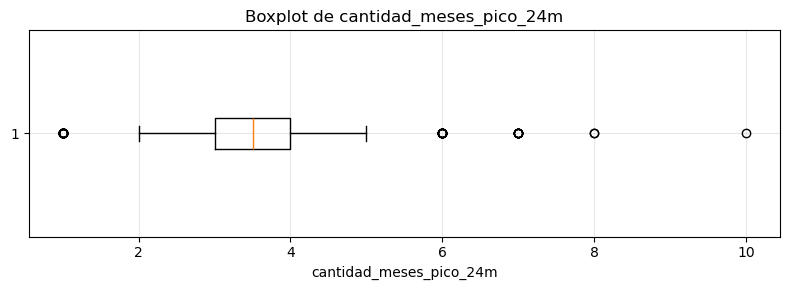

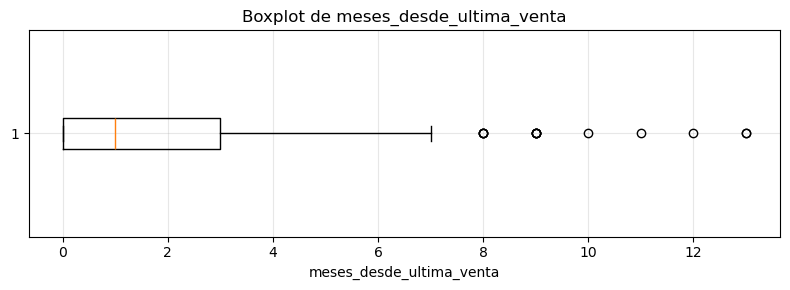

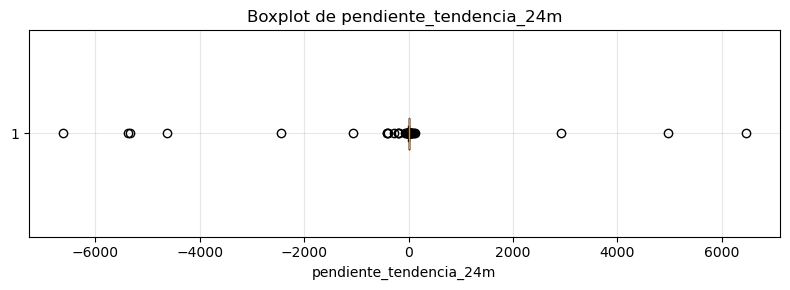

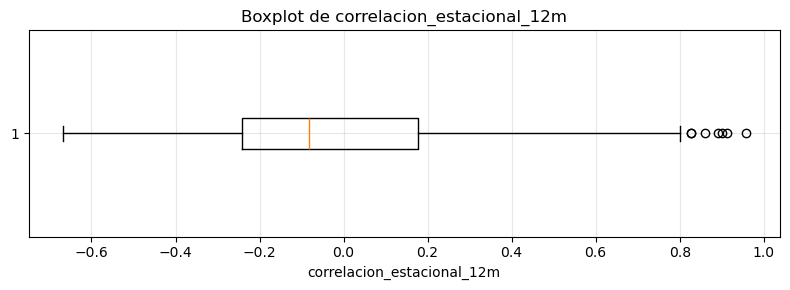

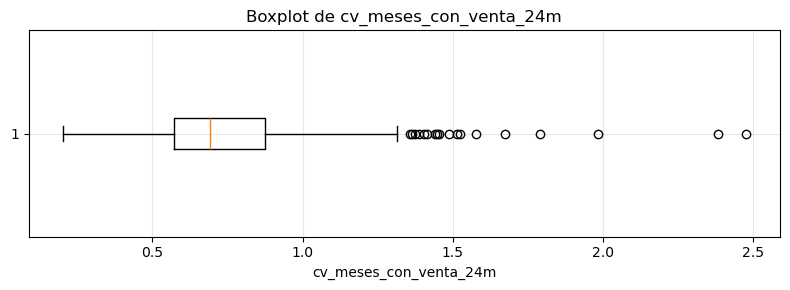

In [167]:
# ============================================================
# 5. Boxplots individuales por variable
# ============================================================
# Ayudan a detectar visualmente valores atípicos.
# ============================================================

for variable in variables_cluster_final:
    plt.figure(figsize=(8, 3))

    plt.boxplot(
        X_base[variable].dropna(),
        vert=False
    )

    plt.title(f"Boxplot de {variable}")
    plt.xlabel(variable)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [168]:
# ============================================================
# 2. Estadística descriptiva ampliada
# ============================================================
# Se incluyen percentiles bajos y altos para detectar colas largas,
# concentración de valores y posibles outliers.
# ============================================================

resumen_distribucion = (
   X_base.describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
    .T
    .round(2)
)

resumen_distribucion

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
total_unidades_vendidas_24m,450.0,84939.83,583677.71,12.00,12.49,15.00,17.00,30.00,69.00,367.50,2066.67,69246.41,3111238.28,6219703.00
conteo_facturas_24m,450.0,21.89,23.82,6.00,6.00,7.00,7.00,9.25,14.00,24.00,42.10,66.55,122.02,212.00
ratio_venta_reciente_6m,450.0,0.84,0.56,0.00,0.00,0.00,0.19,0.43,0.76,1.14,1.58,1.90,2.52,3.10
cantidad_meses_pico_24m,450.0,3.49,1.37,1.00,1.00,1.00,2.00,3.00,3.50,4.00,5.00,6.00,7.00,10.00
meses_desde_ultima_venta,450.0,1.80,2.19,0.00,0.00,0.00,0.00,0.00,1.00,3.00,5.00,6.00,9.51,13.00
pendiente_tendencia_24m,450.0,-28.07,675.59,-6622.84,-1764.90,-3.00,-0.54,-0.12,-0.03,0.07,0.65,2.63,96.81,6461.30
correlacion_estacional_12m,450.0,-0.01,0.30,-0.67,-0.46,-0.38,-0.32,-0.24,-0.08,0.18,0.43,0.58,0.84,0.96
cv_meses_con_venta_24m,450.0,0.74,0.28,0.20,0.31,0.39,0.44,0.57,0.69,0.87,1.04,1.26,1.63,2.48


In [169]:
# ============================================================
# 2. Función de diagnóstico por variable
# ============================================================
# Calcula métricas necesarias para decidir si una variable requiere:
# - winsorización
# - transformación logarítmica
# - transformación Yeo-Johnson
# - ninguna transformación
# ============================================================

def diagnosticar_variable(serie):
    serie = (
        pd.to_numeric(serie, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    return {
        "media": serie.mean(),
        "mediana": serie.median(),
        "std": serie.std(),
        "min": serie.min(),
        "max": serie.max(),
        "skewness": serie.skew(),
        "kurtosis": serie.kurtosis(),
        "p01": serie.quantile(0.01),
        "p05": serie.quantile(0.05),
        "p95": serie.quantile(0.95),
        "p97": serie.quantile(0.97)
    }

In [170]:
# ============================================================
# 2. Diagnóstico de distribución por variable
# ============================================================
# Se calculan métricas de forma para decidir el tratamiento:
#
# - skewness: mide el sesgo de la distribución.
# - kurtosis: mide colas pesadas o presencia de outliers.
# - min: permite detectar valores negativos.
# - ratio_max_p99: indica qué tan extremo es el valor máximo
#   respecto al percentil 99.
# ============================================================

diagnostico_transformacion = pd.DataFrame({
    "media": X_base.mean(),
    "mediana": X_base.median(),
    "std": X_base.std(),
    "min": X_base.min(),
    "max": X_base.max(),
    "skewness": X_base.skew(),
    "kurtosis": X_base.kurtosis(),
    "p01": X_base.quantile(0.01),
    "p95": X_base.quantile(0.95),
    "p99": X_base.quantile(0.97)
})

diagnostico_transformacion["ratio_max_p99"] = (
    diagnostico_transformacion["max"] /
    diagnostico_transformacion["p99"].replace(0, np.nan)
)
diagnostico_transformacion["ratio_min_p01"] = (
    abs(diagnostico_transformacion["min"]) /
    abs(diagnostico_transformacion["p01"].replace(0, np.nan))
)

diagnostico_transformacion = diagnostico_transformacion.round(2)

diagnostico_transformacion.sort_values("skewness", ascending=False)

,media,mediana,std,min,max,skewness,kurtosis,p01,p95,p99,ratio_max_p99,ratio_min_p01
total_unidades_vendidas_24m,84939.83,69.00,583677.71,12.00,6219703.00,8.48,75.82,12.49,69246.41,294042.47,21.15,0.96
conteo_facturas_24m,21.89,14.00,23.82,6.00,212.00,3.92,21.14,6.00,66.55,84.06,2.52,1.00
meses_desde_ultima_venta,1.80,1.00,2.19,0.00,13.00,2.00,5.19,0.00,6.00,7.53,1.73,NaN
cv_meses_con_venta_24m,0.74,0.69,0.28,0.20,2.48,1.71,6.05,0.31,1.26,1.40,1.77,0.65
ratio_venta_reciente_6m,0.84,0.76,0.56,0.00,3.10,0.88,0.95,0.00,1.90,2.04,1.52,NaN
correlacion_estacional_12m,-0.01,-0.08,0.30,-0.67,0.96,0.87,0.32,-0.46,0.58,0.67,1.43,1.45
cantidad_meses_pico_24m,3.49,3.50,1.37,1.00,10.00,0.50,1.07,1.00,6.00,6.00,1.67,1.00
pendiente_tendencia_24m,-28.07,-0.03,675.59,-6622.84,6461.30,-2.00,66.85,-1764.90,2.63,20.16,320.47,3.75


In [171]:
# ============================================================
# 3. Función para decidir winsorización
# ============================================================
# La winsorización se aplica cuando existe evidencia de colas extremas.
#
# Criterios:
# - kurtosis >= 10: colas pesadas / outliers severos.
# - abs(skewness) >= 2 y kurtosis >= 5: sesgo fuerte con colas relevantes.
#
# Se aplica antes de otras transformaciones para reducir la influencia
# de valores extremos sobre el proceso posterior.
# ============================================================

def debe_winsorizar(
    skewness,
    kurtosis,
    umbral_kurtosis_extrema=10,
    umbral_skew_extremo=2,
    umbral_kurtosis_moderada=5
):
    if kurtosis >= umbral_kurtosis_extrema:
        return True

    if abs(skewness) >= umbral_skew_extremo and kurtosis >= umbral_kurtosis_moderada:
        return True

    return False

In [172]:
def winsorizar(X):
    limite_inferior = X.quantile(0.01)
    limite_superior = X.quantile(0.97)

    X_winsorizado=X.clip(lower=limite_inferior, upper=limite_superior)
    return X_winsorizado

In [173]:
# ============================================================
# 3. Función para sugerir transformación por variable
# ============================================================
# Reglas utilizadas:
#Skewness = hacia dónde se estira la distribución.
#Kurtosis = qué tan pesadas o extremas son sus colas.Kurtosis me dice si hay valores extremos que pueden dominar las distancias del clustering.
#

# 1. Si la variable tiene valores negativos:
#    - No se puede aplicar log1p directamente.
#    - Si tiene alto sesgo o alta curtosis, se sugiere Yeo-Johnson.
#
# 2. Si la variable es no negativa y tiene skewness alto:
#    - Se sugiere log1p para comprimir la cola derecha.
#
# 3. Si la variable tiene sesgo moderado:
#    - Se puede usar Yeo-Johnson o dejar sin transformación fuerte.
#
# 4. Si la variable tiene rango natural limitado, como correlaciones:
#    - Se conserva sin transformación.
# ============================================================
def sugerir_transformacion_variable(
    serie,
    nombre_variable,
    umbral_skew=1.0,
    umbral_kurtosis=10.0
):
    """
    Sugiere una transformación según:
    - presencia de valores negativos
    - skewness
    - kurtosis
    - naturaleza de la variable
    """

    serie = (
        pd.to_numeric(serie, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    skewness = serie.skew()
    kurtosis = serie.kurtosis()
    minimo = serie.min()

    # Variables con rango natural de correlación
    if "correlacion" in nombre_variable.lower():
        return "sin_transformacion"

    # Variables con valores negativos
    if minimo < 0:
        if abs(skewness) >= umbral_skew or kurtosis >= umbral_kurtosis:
            return "yeo_johnson"
        else:
            return "sin_transformacion"

    # Variables no negativas con sesgo positivo o colas pesadas
    if skewness >= umbral_skew or kurtosis >= umbral_kurtosis:
        return "log1p"

    return "sin_transformacion"

In [175]:

# 5. Aplicar preprocesamiento automático
# ============================================================
# Flujo:
# 1. Diagnosticar variable original.
# 2. Decidir si se winsoriza.
# 3. Aplicar winsorización si corresponde.
# 4. Recalcular diagnóstico.
# 5. Decidir transformación.
# 6. Aplicar transformación.
# 7. Guardar decisiones para trazabilidad metodológica.
# ============================================================

X_preprocesada = X_base.copy()

registro_preprocesamiento = []
transformadores_yeo_johnson = {}

for variable in X_base.columns:

    # --------------------------------------------------------
    # 5.1 Diagnóstico original
    # --------------------------------------------------------

    diagnostico_original = diagnosticar_variable(X_base[variable])

    skew_original = diagnostico_original["skewness"]
    kurtosis_original = diagnostico_original["kurtosis"]

    # --------------------------------------------------------
    # 5.2 Decidir winsorización
    # --------------------------------------------------------

    aplicar_winsor = debe_winsorizar(
        skewness=skew_original,
        kurtosis=kurtosis_original
    )

    serie_tratada = X_base[variable].copy()


    if aplicar_winsor:
        limite_inferior= diagnostico_original["p01"]
        limite_superior= diagnostico_original["p97"]
        serie_tratada=winsorizar(serie_tratada)
        # limite_inferior = diagnostico_original["p01"]
        # limite_superior = diagnostico_original["p97"]

        # serie_tratada = serie_tratada.clip(
        #     lower=limite_inferior,
        #     upper=limite_superior
        # )
    else:
        limite_inferior = np.nan
        limite_superior = np.nan

    # --------------------------------------------------------
    # 5.3 Decidir transformación posterior a winsorización
    # --------------------------------------------------------

    transformacion = sugerir_transformacion_variable(
        serie=serie_tratada,
        nombre_variable=variable
    )

    # --------------------------------------------------------
    # 5.4 Aplicar transformación
    # --------------------------------------------------------

    if transformacion == "log1p":
        serie_transformada = np.log1p(serie_tratada)

    elif transformacion == "yeo_johnson":
        pt = PowerTransformer(method="yeo-johnson", standardize=False)

        serie_transformada = pt.fit_transform(
            serie_tratada.values.reshape(-1, 1)
        ).ravel()

        transformadores_yeo_johnson[variable] = pt

    else:
        serie_transformada = serie_tratada

    # Guardar variable procesada
    X_preprocesada[variable] = serie_transformada

    # --------------------------------------------------------
    # 5.5 Diagnóstico final
    # --------------------------------------------------------

    diagnostico_final = diagnosticar_variable(X_preprocesada[variable])

    registro_preprocesamiento.append({
        "variable": variable,

        "skewness_antes": diagnostico_original["skewness"],
        "kurtosis_antes": diagnostico_original["kurtosis"],
        "min_antes": diagnostico_original["min"],
        "max_antes": diagnostico_original["max"],

        "winsorizado": aplicar_winsor,
        "limite_inferior_winsor": limite_inferior,
        "limite_superior_winsor": limite_superior,

        "transformacion_aplicada": transformacion,

        "skewness_despues": diagnostico_final["skewness"],
        "kurtosis_despues": diagnostico_final["kurtosis"],
        "min_despues": diagnostico_final["min"],
        "max_despues": diagnostico_final["max"]
    })

df_registro_preprocesamiento = pd.DataFrame(registro_preprocesamiento).round(2)

df_registro_preprocesamiento.sort_values(by="skewness_antes", ascending=False)

,variable,skewness_antes,kurtosis_antes,min_antes,max_antes,winsorizado,limite_inferior_winsor,limite_superior_winsor,transformacion_aplicada,skewness_despues,kurtosis_despues,min_despues,max_despues
0,total_unidades_vendidas_24m,8.48,75.82,12.00,6219703.00,True,12.49,294042.47,log1p,1.70,2.64,2.60,12.59
1,conteo_facturas_24m,3.92,21.14,6.00,212.00,True,6.00,84.06,log1p,0.81,-0.06,1.95,4.44
4,meses_desde_ultima_venta,2.00,5.19,0.00,13.00,False,NaN,NaN,log1p,0.37,-0.79,0.00,2.64
7,cv_meses_con_venta_24m,1.71,6.05,0.20,2.48,False,NaN,NaN,log1p,0.85,1.88,0.18,1.25
2,ratio_venta_reciente_6m,0.88,0.95,0.00,3.10,False,NaN,NaN,sin_transformacion,0.88,0.95,0.00,3.10
6,correlacion_estacional_12m,0.87,0.32,-0.67,0.96,False,NaN,NaN,sin_transformacion,0.87,0.32,-0.67,0.96
3,cantidad_meses_pico_24m,0.50,1.07,1.00,10.00,False,NaN,NaN,sin_transformacion,0.50,1.07,1.00,10.00
5,pendiente_tendencia_24m,-2.00,66.85,-6622.84,6461.30,True,-1764.90,20.16,yeo_johnson,1.50,15.83,-69.81,68.86


In [176]:
# ============================================================
# 4. Aplicar reglas de decisión a todas las variables
# ============================================================

decisiones_transformacion = []

for variable in X_base.columns:
    decision = sugerir_transformacion_variable(
        serie=X_base[variable],
        nombre_variable=variable
    )
    diagnostico_original = diagnosticar_variable(X_base[variable])

    skewness_=diagnostico_original["skewness"]
    kurtosis_=diagnostico_original["kurtosis"]


    winsorizacion_diagnostico=debe_winsorizar(skewness_, kurtosis_)

    decisiones_transformacion.append({
        "variable": variable,
        "winsorizacion":winsorizacion_diagnostico,
        "transformacion_sugerida": decision,
        "min": X_base[variable].min(),
        "max": X_base[variable].max(),
        "skewness": X_base[variable].skew(),
        "kurtosis": X_base[variable].kurtosis(),
        "p99": X_base[variable].quantile(0.99)
    })

df_decisiones_transformacion = pd.DataFrame(decisiones_transformacion)

df_decisiones_transformacion = df_decisiones_transformacion.round(2)

df_decisiones_transformacion.sort_values(
    ["transformacion_sugerida", "skewness"],
    ascending=[True, False]
)

,variable,winsorizacion,transformacion_sugerida,min,max,skewness,kurtosis,p99
0,total_unidades_vendidas_24m,True,log1p,12.00,6219703.00,8.48,75.82,3111238.28
1,conteo_facturas_24m,True,log1p,6.00,212.00,3.92,21.14,122.02
4,meses_desde_ultima_venta,False,log1p,0.00,13.00,2.00,5.19,9.51
7,cv_meses_con_venta_24m,False,log1p,0.20,2.48,1.71,6.05,1.63
2,ratio_venta_reciente_6m,False,sin_transformacion,0.00,3.10,0.88,0.95,2.52
6,correlacion_estacional_12m,False,sin_transformacion,-0.67,0.96,0.87,0.32,0.84
3,cantidad_meses_pico_24m,False,sin_transformacion,1.00,10.00,0.50,1.07,7.00
5,pendiente_tendencia_24m,True,yeo_johnson,-6622.84,6461.30,-2.00,66.85,96.81


In [177]:
# ============================================================
# 5. Aplicar transformaciones según la decisión automática
# ============================================================
# Se genera una nueva matriz X_preprocesada.
#
# - log1p: se aplica a variables no negativas con sesgo positivo.
# - yeo_johnson: se aplica a variables con negativos o outliers severos.
# - sin_transformacion: se conserva la variable original.
# ============================================================

X_preprocesada = X_base.copy()

variables_winsorizar= df_decisiones_transformacion.loc[
    df_decisiones_transformacion["winsorizacion"] == True,
    "variable"
].tolist()

variables_log1p = df_decisiones_transformacion.loc[
    df_decisiones_transformacion["transformacion_sugerida"] == "log1p",
    "variable"
].tolist()

variables_yeo_johnson = df_decisiones_transformacion.loc[
    df_decisiones_transformacion["transformacion_sugerida"] == "yeo_johnson",
    "variable"
].tolist()

variables_sin_transformacion = df_decisiones_transformacion.loc[
    df_decisiones_transformacion["transformacion_sugerida"] == "sin_transformacion",
    "variable"
].tolist()

print("-"*60)
print("\nVariables a Winsorizar:")
print(variables_winsorizar)
print("-"*60)
print("\nVariables con log1p:")
print(variables_log1p)
print("-"*60)
print("\nVariables con Yeo-Johnson:")
print(variables_yeo_johnson)
print("-"*60)
print("\nVariables sin transformación:")
print(variables_sin_transformacion)

------------------------------------------------------------

Variables a Winsorizar:
['total_unidades_vendidas_24m', 'conteo_facturas_24m', 'pendiente_tendencia_24m']
------------------------------------------------------------

Variables con log1p:
['total_unidades_vendidas_24m', 'conteo_facturas_24m', 'meses_desde_ultima_venta', 'cv_meses_con_venta_24m']
------------------------------------------------------------

Variables con Yeo-Johnson:
['pendiente_tendencia_24m']
------------------------------------------------------------

Variables sin transformación:
['ratio_venta_reciente_6m', 'cantidad_meses_pico_24m', 'correlacion_estacional_12m']


In [178]:
# ============================================================
# 5.0 Aplicar Winsorizado
# ============================================================
for variable in variables_winsorizar:
    X_preprocesada[variable] = winsorizar(X_preprocesada[variable])

In [179]:
# ============================================================
# 5.1 Aplicar log1p
# ============================================================
# log1p(x) = log(1 + x)
#
# Se usa en variables no negativas para comprimir valores extremos
# y reducir colas largas hacia la derecha.
# ============================================================

for variable in variables_log1p:
    X_preprocesada[variable] = np.log1p(X_preprocesada[variable])

In [180]:
# 5.2 Aplicar Yeo-Johnson
# ============================================================
# Yeo-Johnson permite transformar variables con valores positivos,
# cero y negativos.
#
# Es útil para variables como pendiente_tendencia_24m, donde existen
# valores negativos y outliers extremos.
# ============================================================

transformadores_yeo_johnson = {}

for variable in variables_yeo_johnson:
    pt = PowerTransformer(method="yeo-johnson", standardize=False)

    X_preprocesada[[variable]] = pt.fit_transform(X_preprocesada[[variable]])

    transformadores_yeo_johnson[variable] = pt

In [181]:
# ============================================================
# 6. Comparar estadística antes y después de transformación
# ============================================================

diagnostico_antes = pd.DataFrame({
    "skewness_antes": X_base.skew(),
    "kurtosis_antes": X_base.kurtosis(),
    "min_antes": X_base.min(),
    "max_antes": X_base.max()
})

diagnostico_despues = pd.DataFrame({
    "skewness_despues": X_preprocesada.skew(),
    "kurtosis_despues": X_preprocesada.kurtosis(),
    "min_despues": X_preprocesada.min(),
    "max_despues": X_preprocesada.max()
})

comparacion_transformacion = pd.concat(
    [diagnostico_antes, diagnostico_despues],
    axis=1
).round(2)

comparacion_transformacion["transformacion_aplicada"] = (
    df_decisiones_transformacion
    .set_index("variable")
    .loc[comparacion_transformacion.index, "transformacion_sugerida"]
)

comparacion_transformacion.sort_values("skewness_antes", ascending=False)

,skewness_antes,kurtosis_antes,min_antes,max_antes,skewness_despues,kurtosis_despues,min_despues,max_despues,transformacion_aplicada
total_unidades_vendidas_24m,8.48,75.82,12.00,6219703.00,1.70,2.64,2.60,12.59,log1p
conteo_facturas_24m,3.92,21.14,6.00,212.00,0.81,-0.06,1.95,4.44,log1p
meses_desde_ultima_venta,2.00,5.19,0.00,13.00,0.37,-0.79,0.00,2.64,log1p
cv_meses_con_venta_24m,1.71,6.05,0.20,2.48,0.85,1.88,0.18,1.25,log1p
ratio_venta_reciente_6m,0.88,0.95,0.00,3.10,0.88,0.95,0.00,3.10,sin_transformacion
correlacion_estacional_12m,0.87,0.32,-0.67,0.96,0.87,0.32,-0.67,0.96,sin_transformacion
cantidad_meses_pico_24m,0.50,1.07,1.00,10.00,0.50,1.07,1.00,10.00,sin_transformacion
pendiente_tendencia_24m,-2.00,66.85,-6622.84,6461.30,1.50,15.83,-69.81,68.86,yeo_johnson


In [183]:
# ============================================================
# Escalamiento robusto posterior al preprocesamiento
# ============================================================

from sklearn.preprocessing import RobustScaler

scaler_robust = RobustScaler()

X_scaled= pd.DataFrame(
    scaler_robust.fit_transform(X_preprocesada),
    columns=X_preprocesada.columns,
    index=X_preprocesada.index
)

X_scaled.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
total_unidades_vendidas_24m,450.0,0.32,0.95,-0.67,-0.33,0.0,0.67,3.37
conteo_facturas_24m,450.0,0.15,0.72,-0.85,-0.43,0.0,0.57,1.94
ratio_venta_reciente_6m,450.0,0.11,0.79,-1.06,-0.47,0.0,0.53,3.26
cantidad_meses_pico_24m,450.0,-0.01,1.37,-2.50,-0.50,0.0,0.50,6.50
meses_desde_ultima_venta,450.0,0.07,0.49,-0.50,-0.50,0.0,0.50,1.40
pendiente_tendencia_24m,450.0,5.51,80.83,-371.62,-0.45,0.0,0.55,366.91
correlacion_estacional_12m,450.0,0.17,0.72,-1.40,-0.38,0.0,0.62,2.48
cv_meses_con_venta_24m,450.0,0.11,0.86,-1.94,-0.42,0.0,0.58,4.10


In [185]:
# ============================================================
# 9. Evaluación del número óptimo de clusters
# ============================================================
# En esta sección se prueban distintos valores de k para K-Means.
#
# Métricas evaluadas:
# - Inertia: compactación interna de los clusters. Menor es mejor.
# - Silhouette Score: separación y cohesión de clusters. Mayor es mejor.
# - Davies-Bouldin Index: similitud entre clusters. Menor es mejor.
# - Calinski-Harabasz Score: separación entre clusters. Mayor es mejor.
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

resultados_k = []

rango_k = range(2, 10)

for k in rango_k:
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = modelo_kmeans.fit_predict(X_scaled)
    
    inertia = modelo_kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    
    resultados_k.append({
        "k": k,
        "inertia": inertia,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
        "calinski_harabasz_score": calinski_harabasz
    })

df_resultados_k = pd.DataFrame(resultados_k)

df_resultados_k

c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\tesis_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\tesis_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\tesis_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\CHOPPE\Documents\CE

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,1.001093e+06,0.946909,0.086438,865.830807
1,3,2.164449e+05,0.954317,0.242960,2808.057588
2,4,9.066871e+04,0.944779,0.185212,4665.175851
3,5,4.987558e+04,0.945945,0.270728,6437.339815
4,6,3.715856e+04,0.892082,0.351914,6927.203086
5,7,2.586244e+04,0.883497,0.371934,8307.606191
6,8,2.034006e+04,0.882873,0.334127,9050.827414
7,9,1.586528e+04,0.884933,0.294093,10145.728511


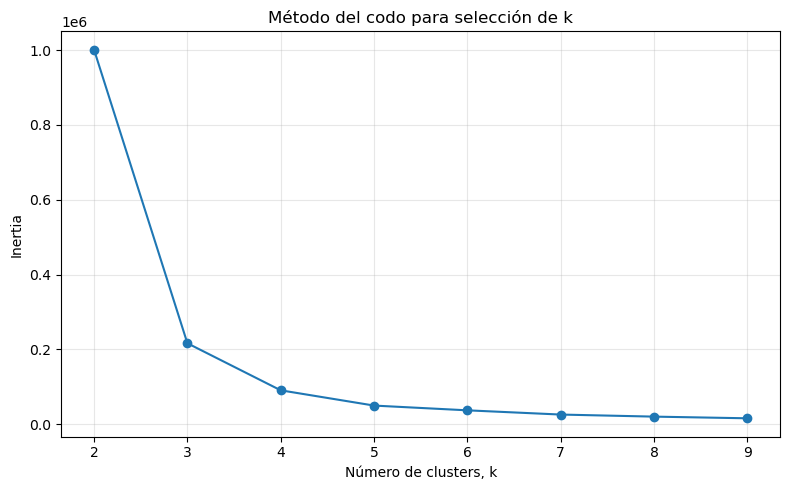

In [186]:
# ============================================================
# 10. Método del codo
# ============================================================
# La inertia mide la suma de distancias internas dentro de cada cluster.
# A mayor número de clusters, la inertia siempre baja.
#
# El objetivo es identificar el punto donde agregar más clusters
# ya no mejora significativamente la compactación.
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_k["k"],
    df_resultados_k["inertia"],
    marker="o"
)

plt.title("Método del codo para selección de k")
plt.xlabel("Número de clusters, k")
plt.ylabel("Inertia")
plt.xticks(list(rango_k))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

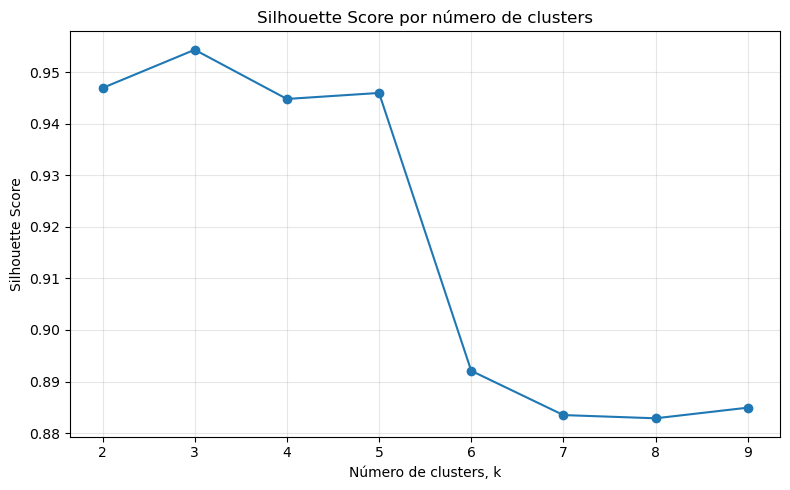

In [187]:
# ============================================================
# 11. Silhouette Score por número de clusters
# ============================================================
# El Silhouette Score mide qué tan bien separado está cada punto
# respecto a su propio cluster y a los clusters vecinos.
#
# Valores más altos indican mejor separación.
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_k["k"],
    df_resultados_k["silhouette_score"],
    marker="o"
)

plt.title("Silhouette Score por número de clusters")
plt.xlabel("Número de clusters, k")
plt.ylabel("Silhouette Score")
plt.xticks(list(rango_k))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

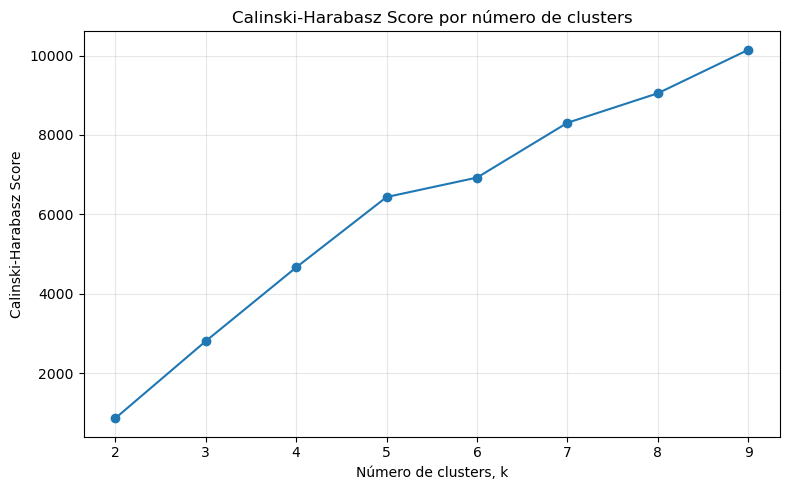

In [188]:
# ============================================================
# 13. Calinski-Harabasz Score por número de clusters
# ============================================================
# Esta métrica compara la separación entre clusters contra
# la dispersión interna de cada cluster.
#
# Valores más altos indican mejor estructura de agrupamiento.
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_k["k"],
    df_resultados_k["calinski_harabasz_score"],
    marker="o"
)

plt.title("Calinski-Harabasz Score por número de clusters")
plt.xlabel("Número de clusters, k")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(list(rango_k))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [189]:
# ============================================================
# 14. Tabla comparativa de métricas por k
# ============================================================

df_resultados_k.sort_values(
    by="silhouette_score",
    ascending=False
).head(10)

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
1,3,2.164449e+05,0.954317,0.242960,2808.057588
0,2,1.001093e+06,0.946909,0.086438,865.830807
3,5,4.987558e+04,0.945945,0.270728,6437.339815
2,4,9.066871e+04,0.944779,0.185212,4665.175851
4,6,3.715856e+04,0.892082,0.351914,6927.203086
7,9,1.586528e+04,0.884933,0.294093,10145.728511
5,7,2.586244e+04,0.883497,0.371934,8307.606191
6,8,2.034006e+04,0.882873,0.334127,9050.827414
